# Notebook 4: Train From Scratch — Why Transfer Learning Matters

**The experiment:** Same ResNet18 architecture, same flower data, but
**random weights** instead of pretrained ImageNet weights.

**Prediction before running:** With only ~10 images per class, a randomly
initialized network should badly overfit the training set while performing
poorly on validation. This proves the pretrained features are doing the
heavy lifting.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
from torchvision import models
from src.data import get_dataloaders
from src.model import count_parameters
from src.train import train_model
from src.evaluate import plot_training_history

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(data_dir='../data', batch_size=32)

Train: 1020 images
Val:   1020 images
Test:  6149 images
Classes: 10 images/class avg, 102 classes


In [3]:
# ---- Model with RANDOM weights (no pretraining) ----
# weights=None → random initialization
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 102)
)
model_scratch = model_scratch.to(DEVICE)

# ALL parameters are trainable — nothing is pretrained
count_parameters(model_scratch)

Total parameters:     11,334,054
Trainable parameters: 11,334,054  (100.0%)
Frozen parameters:             0  (0.0%)


(11334054, 11334054)

In [4]:
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

history_scratch = train_model(
    model_scratch, train_loader, val_loader, DEVICE,
    optimizer=optimizer, scheduler=scheduler,
    num_epochs=30,  # Give it more epochs — it needs them
    save_path='../models/from_scratch_best.pth'
)

Epoch  1/30 (45s) | Train Loss: 4.6693  Acc: 1.2% | Val Loss: 5.0599  Acc: 2.4% | LR: 1.00e-03
  ✓ Saved best model (val_acc: 2.4%)


Epoch  2/30 (41s) | Train Loss: 4.3043  Acc: 3.9% | Val Loss: 4.2030  Acc: 3.4% | LR: 9.97e-04
  ✓ Saved best model (val_acc: 3.4%)


Epoch  3/30 (36s) | Train Loss: 4.0673  Acc: 4.7% | Val Loss: 3.9283  Acc: 6.7% | LR: 9.89e-04
  ✓ Saved best model (val_acc: 6.7%)


Epoch  4/30 (38s) | Train Loss: 3.9486  Acc: 4.5% | Val Loss: 4.0157  Acc: 5.5% | LR: 9.76e-04


Epoch  5/30 (37s) | Train Loss: 3.8139  Acc: 6.8% | Val Loss: 3.8143  Acc: 7.9% | LR: 9.57e-04
  ✓ Saved best model (val_acc: 7.9%)


...

Epoch 26/30 (1264s) | Train Loss: 2.7232  Acc: 23.7% | Val Loss: 3.0558  Acc: 23.5% | LR: 6.79e-05
  ✓ Saved best model (val_acc: 23.5%)


Epoch 27/30 (35s) | Train Loss: 2.6936  Acc: 27.1% | Val Loss: 3.0497  Acc: 22.6% | LR: 4.42e-05


Epoch 28/30 (31s) | Train Loss: 2.7560  Acc: 23.6% | Val Loss: 3.0439  Acc: 23.2% | LR: 2.54e-05


Epoch 29/30 (32s) | Train Loss: 2.7226  Acc: 24.4% | Val Loss: 3.0370  Acc: 23.9% | LR: 1.19e-05
  ✓ Saved best model (val_acc: 23.9%)


Epoch 30/30 (32s) | Train Loss: 2.7000  Acc: 23.9% | Val Loss: 3.0413  Acc: 23.2% | LR: 3.74e-06

Best validation accuracy: 23.9%


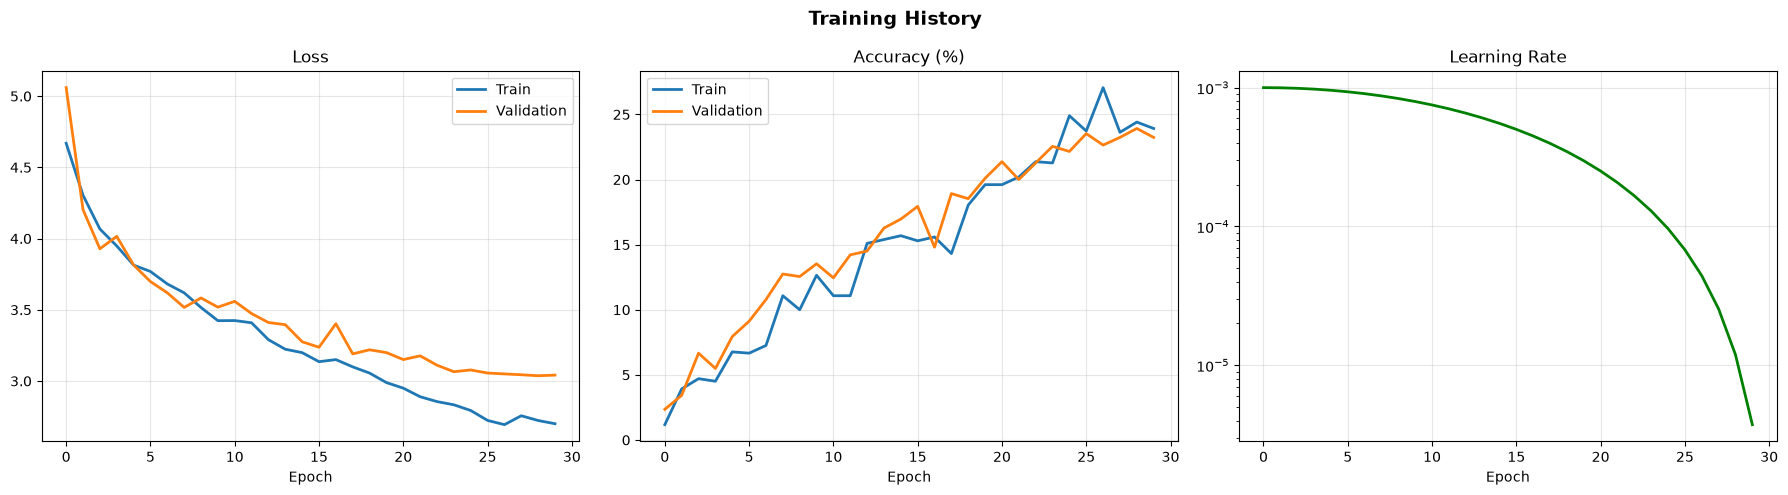

In [5]:
plot_training_history(history_scratch, save_path='../results/from_scratch_curves.png')

In [6]:
# ---- Side-by-side comparison ----
# Load history from Notebook 02 if you saved it, or re-run.
# The key comparison:
#   - From scratch:    likely ~20-35% val accuracy
#   - Feature extract: likely ~60-75% val accuracy  (Notebook 01)
#   - Fine-tuned:      likely ~80-90% val accuracy  (Notebook 02)
#
# QUESTION TO ANSWER: Where does the ~50% accuracy gap come from?
# The architecture is IDENTICAL. The only difference is the starting weights.
# This proves that ImageNet features transfer to flowers.

## What to observe

1. **Training accuracy** may still get high — the model memorizes 1,020 images
2. **Validation accuracy** stays much lower — it hasn't learned generalizable features
3. **The gap** = overfitting. With only 10 images/class, there's not enough data
   to learn edges, textures, shapes from scratch
4. **Transfer learning** gives you those features for free from ImageNet's 1.2M images